In [1]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
# ls binaural_model_attn_stage_reps/word_task_half_co_loc_v07

In [25]:
# Get model activation files 
from pathlib import Path 

out_dir = Path('binaural_model_attn_stage_reps/')
# paths = list(out_dir.glob('*model_activations_0dB.h5'))

# path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v08_gender_bal_4M_orig_model_activations_0dB_compare_with_attn.h5")
path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v3.h5")
layer_shape_dict = pickle.load(open(path.parent/'word_task_half_co_loc_v07_layer_shape_dict.pkl', 'rb'))

In [5]:
# corrs  = pickle.load(open("binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v3_corrs.pkl", 'rb'))

In [39]:
def get_frames_per_sec(n_frames, dur):
    return n_frames/dur

def get_frames_for_context(context_len, rate):
    return int(context_len*rate)

# given number of time frames, total signal length and desired context, get frames that correspond to that context centered on the middle of the signal 
def get_context_frames(n_frames, dur, context_len):
    rate = get_frames_per_sec(n_frames, dur)
    context_frames = get_frames_for_context(context_len, rate)
    return n_frames//2 - context_frames//2, n_frames//2 + context_frames//2 + 1 

# sanity check outputs 
print(get_frames_per_sec(50, 2))
print(get_frames_for_context(.0010, 1000))
print(get_context_frames(63, 2, 0.5))

25.0
1
(24, 39)


In [6]:
acts =  h5py.File(path, 'r')
print(acts.keys())
acts.close()


<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

# Talker correlation by layer sanity check

#### Compare $\text{corr}(\text{source}_ {\text{cued}},\text{mixture}_ {\text{cued}})$ and $\text{corr}(\text{source}_ {\text{uncued}},\text{mixture}_ {\text{cued}})$ for target and distractor sources 

In [50]:


with h5py.File(path, 'r') as acts:
    print(acts.keys())
    layer_names = set([key.split("_mixture")[0] for key in acts.keys() if "mixture" in key]) # set to remove duplicates 
    print(layer_names)
    corr_results = {}

    out_name = f"{path.stem}_corrs_sanity_check.pkl"
    # Save results as dict
    out_name = out_dir / out_name
    print(out_name)
    N_acts = acts["cochleagram_mixture"].shape[0]

    for layer in layer_names:
        mixture_acts = acts[f"{layer}_mixture"]
        target_acts = acts[f"{layer}_fg"]
        bg_acts = acts[f"{layer}_bg"]

        if layer == 'cochleagram':
            fg_wo_cue_acts = None
            bg_wo_cue_acts = None 
        else:
            fg_wo_cue_acts = acts[f"{layer}_fg_no_cue"]
            bg_wo_cue_acts =  acts[f"{layer}_bg_no_cue"] 
        print(layer)
        corr_results[f"{layer}_fg"] = []
        corr_results[f"{layer}_bg"] = []
        if fg_wo_cue_acts is not None:
            corr_results[f"{layer}_fg_no_cue"] = []
            corr_results[f"{layer}_bg_no_cue"] = []
        
        for i in tqdm(range(N_acts), desc=f"Getting correlations from {layer}", leave=False):
            corr_results[f"{layer}_fg"].append(stats.pearsonr(target_acts[i], mixture_acts[i]))
            corr_results[f"{layer}_bg"].append(stats.pearsonr(bg_acts[i], mixture_acts[i]))
            if fg_wo_cue_acts is not None:
                corr_results[f"{layer}_fg_no_cue"].append(stats.pearsonr(fg_wo_cue_acts[i], mixture_acts[i]))
                corr_results[f"{layer}_bg_no_cue"].append(stats.pearsonr(bg_wo_cue_acts[i], mixture_acts[i]))

        
        # set type as float32
        for key in corr_results.keys():
            if len(corr_results[key]) > 0:
                corr_results[key] = np.array(corr_results[key], dtype=np.float32)
        
    out_dict = dict(corr_results=corr_results)

    with open(out_name ,'wb') as f:
        pickle.dump(out_dict, f)


<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

Getting correlations from conv_block_2:   0%|          | 0/100 [00:00<?, ?it/s]

relufc


Getting correlations from relufc:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_4


...

cochleagram


Getting correlations from cochleagram:   0%|          | 0/100 [00:00<?, ?it/s]

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/stats/stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())


conv_block_1


Getting correlations from conv_block_1:   0%|          | 0/100 [00:00<?, ?it/s]

#### Same but measuring cosine similarity

In [20]:
from sklearn.metrics.pairwise import cosine_similarity


with h5py.File(path, 'r') as acts:
    print(acts.keys())
    layer_names = set([key.split("_mixture")[0] for key in acts.keys() if "mixture" in key]) # set to remove duplicates 
    print(layer_names)
    corr_results = {}

    out_name = f"{path.stem}_cos_similarity.pkl"
    # Save results as dict
    out_name = out_dir / out_name
    print(out_name)
    N_acts = acts["cochleagram_mixture"].shape[0]

    for layer in layer_names:
        mixture_acts = acts[f"{layer}_mixture"]
        target_acts = acts[f"{layer}_fg"]
        bg_acts = acts[f"{layer}_bg"]

        if layer == 'cochleagram':
            fg_wo_cue_acts = None
            bg_wo_cue_acts = None 
        else:
            fg_wo_cue_acts = acts[f"{layer}_fg_no_cue"]
            bg_wo_cue_acts =  acts[f"{layer}_bg_no_cue"] 
        print(layer)
        corr_results[f"{layer}_fg"] = []
        corr_results[f"{layer}_bg"] = []
        if fg_wo_cue_acts is not None:
            corr_results[f"{layer}_fg_no_cue"] = []
            corr_results[f"{layer}_bg_no_cue"] = []
        
        for i in tqdm(range(N_acts), desc=f"Getting correlations from {layer}", leave=False):
            corr_results[f"{layer}_fg"].append(cosine_similarity(target_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1)))
            corr_results[f"{layer}_bg"].append(cosine_similarity(bg_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1)))
            if fg_wo_cue_acts is not None:
                corr_results[f"{layer}_fg_no_cue"].append(cosine_similarity(fg_wo_cue_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1)))
                corr_results[f"{layer}_bg_no_cue"].append(cosine_similarity(bg_wo_cue_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1)))

        
        # set type as float32
        for key in corr_results.keys():
            if len(corr_results[key]) > 0:
                corr_results[key] = np.array(corr_results[key], dtype=np.float32)
        
    out_dict = dict(corr_results=corr_results)

    with open(out_name ,'wb') as f:
        pickle.dump(out_dict, f)


<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

conv_block_5


conv_block_3


relufc


conv_block_0


conv_block_6


conv_block_4


cochleagram


conv_block_1


#### Get corrs for middle and edges of signal

In [63]:

TOTAL_SIGNAL_LEN = 2
CONTEXT_LEN = 0.100

with h5py.File(path, 'r') as acts:
    print(acts.keys())
    layer_names = set([key.split("_mixture")[0] for key in acts.keys() if "mixture" in key]) # set to remove duplicates 
    print(layer_names)
    corr_results = {}

    out_name = f"{path.stem}_corrs_middle_frames.pkl"
    # Save results as dict
    out_name = out_dir / out_name
    print(out_name)
    N_acts = acts["cochleagram_mixture"].shape[0]

    for layer in layer_names:
        mixture_acts = acts[f"{layer}_mixture"]
        target_acts = acts[f"{layer}_fg"]
        bg_acts = acts[f"{layer}_bg"]

        # get layer shape
        layer_shape = layer_shape_dict[layer]
        middle_onset, middle_offset = get_context_frames(layer_shape[2], TOTAL_SIGNAL_LEN, CONTEXT_LEN)
        middle_frames = slice(middle_onset, middle_offset)

        if layer == 'cochleagram':
            fg_wo_cue_acts = None
            bg_wo_cue_acts = None 
        else:
            fg_wo_cue_acts = acts[f"{layer}_fg_no_cue"]
            bg_wo_cue_acts =  acts[f"{layer}_bg_no_cue"] 
        print(layer)
        corr_results[f"{layer}_fg"] = []
        corr_results[f"{layer}_bg"] = []
        if fg_wo_cue_acts is not None:
            corr_results[f"{layer}_fg_no_cue"] = []
            corr_results[f"{layer}_bg_no_cue"] = []
        
        for i in tqdm(range(N_acts), desc=f"Getting correlations from {layer}", leave=False):
            corr_results[f"{layer}_fg"].append(stats.pearsonr(target_acts[i].reshape(layer_shape)[...,middle_frames].flatten(), mixture_acts[i].reshape(layer_shape)[...,middle_frames].flatten()))
            corr_results[f"{layer}_bg"].append(stats.pearsonr(bg_acts[i].reshape(layer_shape)[...,middle_frames].flatten(), mixture_acts[i].reshape(layer_shape)[...,middle_frames].flatten()))
            if fg_wo_cue_acts is not None:
                corr_results[f"{layer}_fg_no_cue"].append(stats.pearsonr(fg_wo_cue_acts[i].reshape(layer_shape)[...,middle_frames].flatten(), mixture_acts[i].reshape(layer_shape)[...,middle_frames].flatten()))
                corr_results[f"{layer}_bg_no_cue"].append(stats.pearsonr(bg_wo_cue_acts[i].reshape(layer_shape)[...,middle_frames].flatten(), mixture_acts[i].reshape(layer_shape)[...,middle_frames].flatten()))

        
        # set type as float32
        for key in corr_results.keys():
            if len(corr_results[key]) > 0:
                corr_results[key] = np.array(corr_results[key], dtype=np.float32)
        
    out_dict = dict(corr_results=corr_results)

    with open(out_name ,'wb') as f:
        pickle.dump(out_dict, f)


<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

Getting correlations from conv_block_4:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_5


Getting correlations from conv_block_5:   0%|          | 0/100 [00:00<?, ?it/s]

cochleagram


...

conv_block_1


Getting correlations from conv_block_1:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_3


Getting correlations from conv_block_3:   0%|          | 0/100 [00:00<?, ?it/s]

IndexError: tuple index out of range

In [67]:
from sklearn.metrics.pairwise import cosine_similarity

TOTAL_SIGNAL_LEN = 2
CONTEXT_LEN = 0.100

with h5py.File(path, 'r') as acts:
    print(acts.keys())
    layer_names = set([key.split("_mixture")[0] for key in acts.keys() if "mixture" in key]) # set to remove duplicates 
    print(layer_names)
    cos_results = {}

    out_name = f"{path.stem}_corrs_middle_frames.pkl"
    # Save results as dict
    out_name = out_dir / out_name
    print(out_name)
    N_acts = acts["cochleagram_mixture"].shape[0]

    for layer in layer_names:
        mixture_acts = acts[f"{layer}_mixture"]
        target_acts = acts[f"{layer}_fg"]
        bg_acts = acts[f"{layer}_bg"]

        # get layer shape
        layer_shape = layer_shape_dict[layer]
        middle_onset, middle_offset = get_context_frames(layer_shape[2], TOTAL_SIGNAL_LEN, CONTEXT_LEN)
        middle_frames = slice(middle_onset, middle_offset)

        if layer == 'cochleagram':
            fg_wo_cue_acts = None
            bg_wo_cue_acts = None 
        else:
            fg_wo_cue_acts = acts[f"{layer}_fg_no_cue"]
            bg_wo_cue_acts =  acts[f"{layer}_bg_no_cue"] 
        print(layer)
        cos_results[f"{layer}_fg"] = []
        cos_results[f"{layer}_bg"] = []
        if fg_wo_cue_acts is not None:
            cos_results[f"{layer}_fg_no_cue"] = []
            cos_results[f"{layer}_bg_no_cue"] = []
        
        for i in tqdm(range(N_acts), desc=f"Getting correlations from {layer}", leave=False):
            cos_results[f"{layer}_fg"].append(cosine_similarity(target_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1), mixture_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1)).squeeze())
            cos_results[f"{layer}_bg"].append(cosine_similarity(bg_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1), mixture_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1)).squeeze())
            if fg_wo_cue_acts is not None:
                cos_results[f"{layer}_fg_no_cue"].append(cosine_similarity(fg_wo_cue_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1), mixture_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1)).squeeze())
                cos_results[f"{layer}_bg_no_cue"].append(cosine_similarity(bg_wo_cue_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1), mixture_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1)).squeeze())

        
        # set type as float32
        for key in cos_results.keys():
            if len(cos_results[key]) > 0:
                cos_results[key] = np.array(cos_results[key], dtype=np.float32)
        
    out_dict = dict(cos_results=cos_results)

    with open(out_name ,'wb') as f:
        pickle.dump(out_dict, f)


<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

Getting correlations from conv_block_4:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_5


Getting correlations from conv_block_5:   0%|          | 0/100 [00:00<?, ?it/s]

cochleagram


...

conv_block_1


Getting correlations from conv_block_1:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_3


Getting correlations from conv_block_3:   0%|          | 0/100 [00:00<?, ?it/s]

IndexError: tuple index out of range

## Plot Results

In [55]:
## Make layer plot 

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import pickle 
import pandas as pd


In [9]:
out_name = f"{path.stem}_cos_similarity.pkl"
# Save results as dict
out_name = out_dir / out_name

In [10]:
out_name

PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v3_cos_similarity.pkl')

In [70]:
# put results into dataframe
# put into df for easy plotting:

# load results

# # out_name = out_dir / f"{paths[0].stem}_corrs.pkl"
# with open("binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v3_corrs_sanity_check.pkl", 'rb') as f:
#     results = pickle.load(f)

# results = out_dict['corr_results']
# results = corr_results

# fg_corr_results = {key.replace('_fg', ''): val[:,0] for key,val in results.items() if '_fg' in key and 'no_cue' not in key}
# bg_corr_results = {key.replace('_bg', ''): val[:,0] for key,val in results.items() if '_bg' in key and 'no_cue' not in key}

# fg_no_cue_corr_results = {key.replace('_fg_no_cue', ''): val[:,0] for key,val in results.items() if '_fg_no_cue' in key}
# bg_no_cue_corr_results = {key.replace('_bg_no_cue', ''): val[:,0] for key,val in results.items() if '_bg_no_cue' in key}

# ## copy over cochleagram results from fg_corr to fg_no_cue becuase these are the same 
# # fg_no_cue_corr_results['cochleagram'] = fg_corr_results['cochleagram']
# # bg_no_cue_corr_results['cochleagram'] = bg_corr_results['cochleagram']


# dfs = []
# for layer in fg_corr_results.keys():
#     df = pd.DataFrame.from_dict({'fg_corrs':fg_corr_results[layer],
#                                  'bg_corrs':bg_corr_results[layer],
#                                  'fg_no_cue_corrs':fg_no_cue_corr_results[layer],
#                                  'bg_no_cue_corrs':bg_no_cue_corr_results[layer],
#                                  'layer': [layer] * len(fg_corr_results[layer])})
            
#     dfs.append(df)
# corr_results = pd.concat(dfs)

# corr_results['layer'] = corr_results['layer'].str.replace('_block_', '')

# results = pd.melt(corr_results, id_vars =['layer'], value_vars=['fg_corrs', 'bg_corrs', 'fg_no_cue_corrs', 'bg_no_cue_corrs'], var_name='Stream',
#                             value_name="Pearson's r")


# results['Stream'].replace('fg_corrs','target with cue',inplace=True)
# results['Stream'].replace('bg_corrs','distractor with cue',inplace=True)
# results['Stream'].replace('fg_no_cue_corrs','target without cue',inplace=True)
# results['Stream'].replace('bg_no_cue_corrs','distractor without cue',inplace=True)

# remove "_block_1" from layer names


# put results into dataframe
# put into df for easy plotting:

# load results

# # out_name = out_dir / f"{paths[0].stem}_cos_sim.pkl"


# results = results['corr_results']
results = cos_results

fg_corr_results = {key.replace('_fg', ''): val.squeeze() for key,val in results.items() if '_fg' in key and 'no_cue' not in key}
bg_corr_results = {key.replace('_bg', ''): val.squeeze() for key,val in results.items() if '_bg' in key and 'no_cue' not in key}

fg_no_cue_corr_results = {key.replace('_fg_no_cue', ''): val.squeeze() for key,val in results.items() if '_fg_no_cue' in key}
bg_no_cue_corr_results = {key.replace('_bg_no_cue', ''): val.squeeze() for key,val in results.items() if '_bg_no_cue' in key}

## copy over cochleagram results from fg_corr to fg_no_cue becuase these are the same 
fg_no_cue_corr_results['cochleagram'] = fg_corr_results['cochleagram']
bg_no_cue_corr_results['cochleagram'] = bg_corr_results['cochleagram']


dfs = []
for layer in fg_corr_results.keys():
    df = pd.DataFrame.from_dict({'fg_cos_sim':fg_corr_results[layer],
                                 'bg_cos_sim':bg_corr_results[layer],
                                 'fg_no_cue_cos_sim':fg_no_cue_corr_results[layer],
                                 'bg_no_cue_cos_sim':bg_no_cue_corr_results[layer],
                                 'layer': [layer] * len(fg_corr_results[layer])})
            
    dfs.append(df)
corr_results = pd.concat(dfs)

corr_results['layer'] = corr_results['layer'].str.replace('_block_', '')

results = pd.melt(corr_results, id_vars =['layer'], value_vars=['fg_cos_sim', 'bg_cos_sim', 'fg_no_cue_cos_sim', 'bg_no_cue_cos_sim'], var_name='Stream',
                            value_name="Cosine similarity")
results['Stream'].replace('fg_cos_sim','target with cue',inplace=True)
results['Stream'].replace('bg_cos_sim','distractor with cue',inplace=True)
results['Stream'].replace('fg_no_cue_cos_sim','target without cue',inplace=True)
results['Stream'].replace('bg_no_cue_cos_sim','distractor without cue',inplace=True)


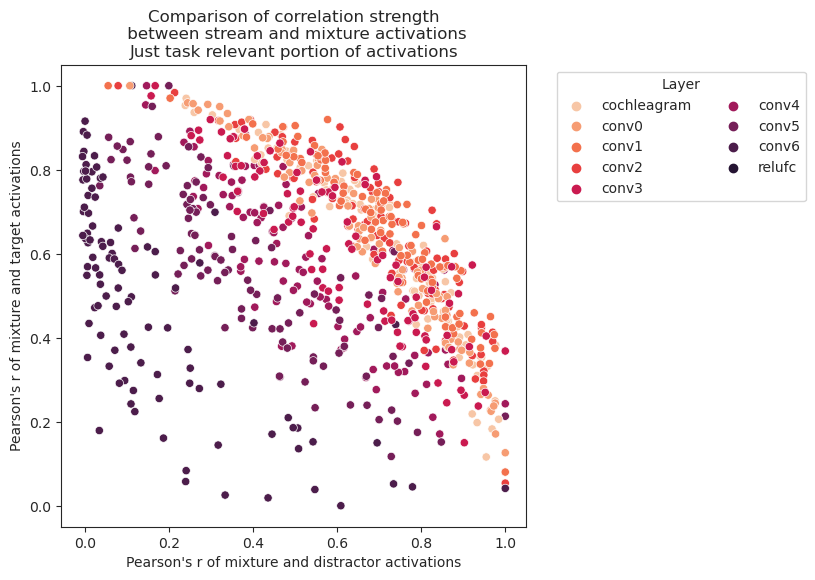

In [65]:

fig, axs = plt.subplots(1, figsize=(6,6))



# order = results.layer.unique()


sns.scatterplot(data=corr_results, x='bg_corrs', y='fg_corrs', hue_order=order,
                hue='layer', palette='rocket_r', ax=axs)

# sns.pointplot(data=results, x='layer', y="Pearson's r", order=order,
#               hue = 'Stream', palette='husl', ax=axs[1],
#              ci=95, n_boot=1000, seed=1)

axs.set_title("Comparison of correlation strength\n between stream and mixture activations\nJust task relevant portion of activations")
axs.set_xlabel("Pearson's r of mixture and distractor activations")
axs.set_ylabel("Pearson's r of mixture and target activations")
axs.legend(title='Layer', ncol=2, frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')
# axs[1].set_ylim(0,1)

# axs[1].set_title("Mixture activations more correlated with\n target activations at later layers")
# axs[1].set_ylabel("Pearson's r")
# rotate x labels for axis 1
# for ax in axs:
#     plt.sca(ax)
#     plt.xticks(rotation=90)

# plt.tight_layout()

Text(0.5, 0.98, 'Task relevant context only')

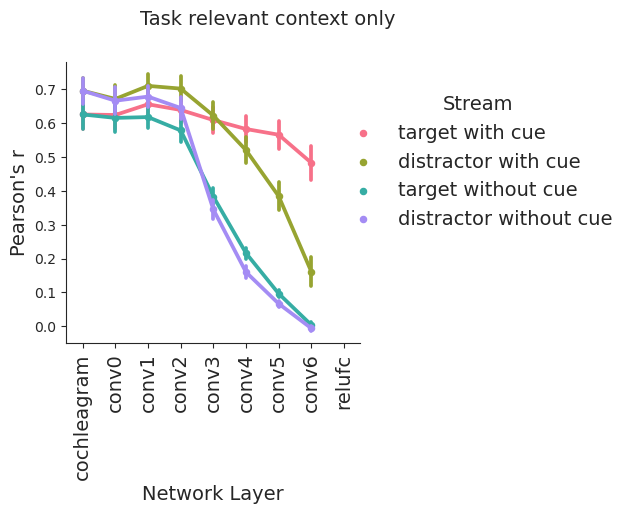

In [66]:
to_plot = results[results['Pearson\'s r'].notna()]
sns.set_style('ticks')

p = sns.catplot(kind='point',data=to_plot, x='layer', y="Pearson's r", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# set y limit to 0,1
# p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("Task relevant context only", size=fontsize)


Text(0.5, 0.98, '50% co-located in training')

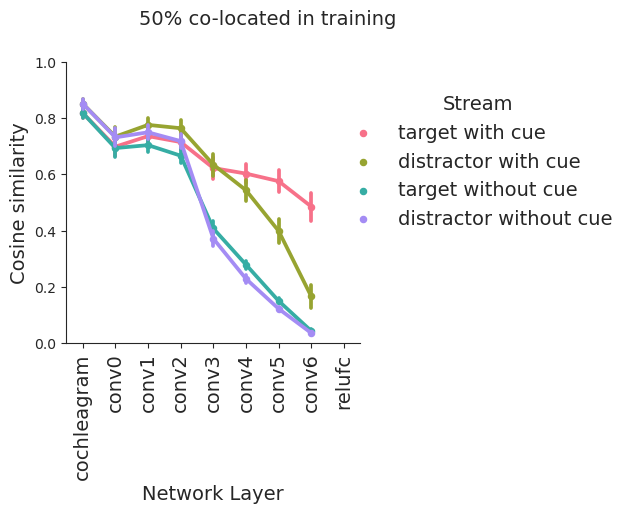

In [71]:
to_plot = results[results['Cosine similarity'].notna()]
sns.set_style('ticks')

p = sns.catplot(kind='point',data=to_plot, x='layer', y="Cosine similarity", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Cosine similarity", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("50% co-located in training", size=fontsize)


### Full activations 

In [20]:
# put results into dataframe
# put into df for easy plotting:

# load results

# # out_name = out_dir / f"{paths[0].stem}_cos_sim.pkl"
# with open("binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v3_cos_sim_sanity_check.pkl", 'rb') as f:
with open(out_name, 'rb') as f:
    results = pickle.load(f)

results = results['corr_results']
# results = out_dict['corr_results']

fg_corr_results = {key.replace('_fg', ''): val.squeeze() for key,val in results.items() if '_fg' in key and 'no_cue' not in key}
bg_corr_results = {key.replace('_bg', ''): val.squeeze() for key,val in results.items() if '_bg' in key and 'no_cue' not in key}

fg_no_cue_corr_results = {key.replace('_fg_no_cue', ''): val.squeeze() for key,val in results.items() if '_fg_no_cue' in key}
bg_no_cue_corr_results = {key.replace('_bg_no_cue', ''): val.squeeze() for key,val in results.items() if '_bg_no_cue' in key}

## copy over cochleagram results from fg_corr to fg_no_cue becuase these are the same 
fg_no_cue_corr_results['cochleagram'] = fg_corr_results['cochleagram']
bg_no_cue_corr_results['cochleagram'] = bg_corr_results['cochleagram']


dfs = []
for layer in fg_corr_results.keys():
    df = pd.DataFrame.from_dict({'fg_cos_sim':fg_corr_results[layer],
                                 'bg_cos_sim':bg_corr_results[layer],
                                 'fg_no_cue_cos_sim':fg_no_cue_corr_results[layer],
                                 'bg_no_cue_cos_sim':bg_no_cue_corr_results[layer],
                                 'layer': [layer] * len(fg_corr_results[layer])})
            
    dfs.append(df)
corr_results = pd.concat(dfs)

corr_results['layer'] = corr_results['layer'].str.replace('_block_', '')

results = pd.melt(corr_results, id_vars =['layer'], value_vars=['fg_cos_sim', 'bg_cos_sim', 'fg_no_cue_cos_sim', 'bg_no_cue_cos_sim'], var_name='Stream',
                            value_name="Cosine similarity")
results['Stream'].replace('fg_cos_sim','target with cue',inplace=True)
results['Stream'].replace('bg_cos_sim','distractor with cue',inplace=True)
results['Stream'].replace('fg_no_cue_cos_sim','target without cue',inplace=True)
results['Stream'].replace('bg_no_cue_cos_sim','distractor without cue',inplace=True)


In [21]:
results['layer'].unique()

array(['conv2', 'conv5', 'conv3', 'relufc', 'conv0', 'conv6', 'conv4',
       'cochleagram', 'conv1'], dtype=object)

In [22]:
order = np.sort(results.layer.unique())


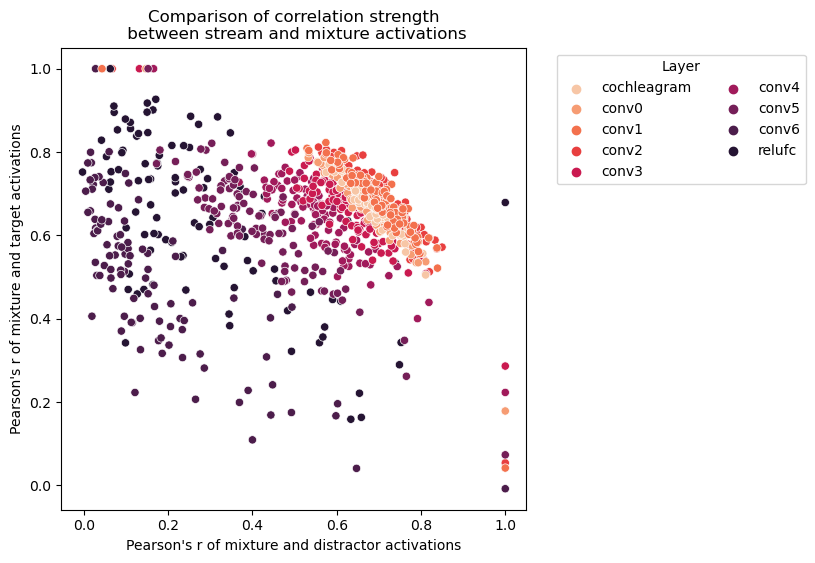

In [79]:

fig, axs = plt.subplots(1, figsize=(6,6))



# order = results.layer.unique()


sns.scatterplot(data=corr_results, x='bg_corrs', y='fg_corrs', hue_order=order,
                hue='layer', palette='rocket_r', ax=axs)

# sns.pointplot(data=results, x='layer', y="Pearson's r", order=order,
#               hue = 'Stream', palette='husl', ax=axs[1],
#              ci=95, n_boot=1000, seed=1)

axs.set_title("Comparison of correlation strength\n between stream and mixture activations")
axs.set_xlabel("Pearson's r of mixture and distractor activations")
axs.set_ylabel("Pearson's r of mixture and target activations")
axs.legend(title='Layer', ncol=2, frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')
# axs[1].set_ylim(0,1)

# axs[1].set_title("Mixture activations more correlated with\n target activations at later layers")
# axs[1].set_ylabel("Pearson's r")
# rotate x labels for axis 1
# for ax in axs:
#     plt.sca(ax)
#     plt.xticks(rotation=90)

# plt.tight_layout()

In [15]:
results[results['Pearson\'s r'].isna()]

,layer,Stream,Pearson's r
80,cochleagram,target,NaN
926,cochleagram,distractor,NaN


Text(0.5, 0.98, '50% co-located in training')

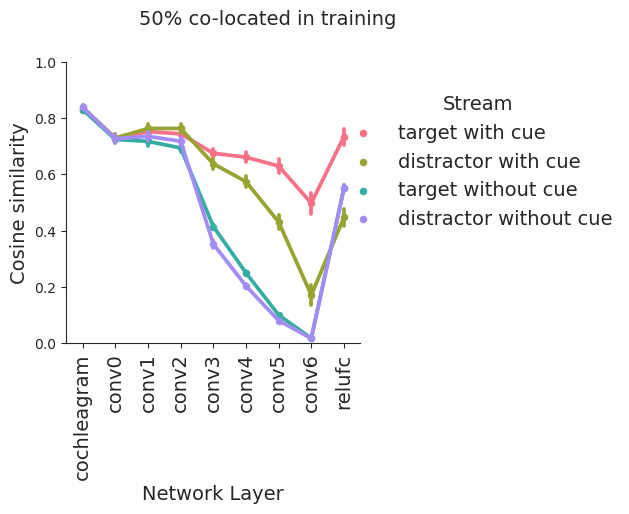

In [ ]:
to_plot = results[results['Cosine similarity'].notna()]
sns.set_style('ticks')

p = sns.catplot(kind='point',data=to_plot, x='layer', y="Cosine similarity", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Cosine similarity", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("50% co-located in training", size=fontsize)


Text(0.5, 0.98, '50% co-located in training')

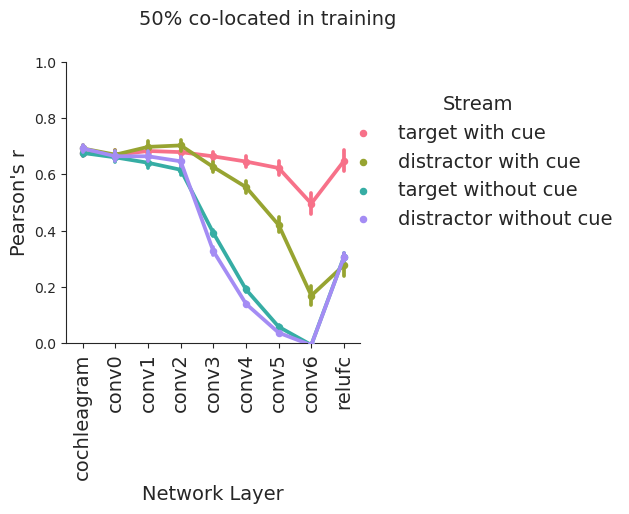

In [81]:
to_plot = results[results['Pearson\'s r'].notna()]
sns.set_style('ticks')

p = sns.catplot(kind='point',data=to_plot, x='layer', y="Pearson's r", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("50% co-located in training", size=fontsize)
